# Week 4 · Day 1 — ML Foundations: Problem Framing, Hold-Out Test & Baseline

**Dataset:** UCI Adult (Census Income)  
**Goal:** Predict whether a person earns **>50K/year** (binary classification)

---

## Task 1 — Problem Definition & Success Metric

### Business Objective
A marketing team wants to send premium product offers **only to high-income individuals** (>50K/year) to maximise conversion rates and avoid wasting budget on unlikely buyers. Every outreach has a cost, so it is better to contact fewer people with a high hit-rate than to blanket a large, diluted list.

### Target Definition
- **Positive class (1):** income **>50K** — the people we want to identify
- **Negative class (0):** income **<=50K**

### Class Base Rate
The dataset contains ~23.9% positives and ~76.1% negatives — a moderately imbalanced binary problem.

### Chosen Primary Metric: **ROC AUC**

| Metric | Why consider it | Why not primary here |
|--------|----------------|----------------------|
| Accuracy | Easy to explain | Misleading on imbalanced data; 76% accuracy by always predicting <=50K |
| Precision | Minimises wasted outreach | Does not capture how many high-earners we actually find |
| Recall | Captures all high-earners | Can balloon the contact list with false positives, destroying ROI |
| **ROC AUC** | **Threshold-free rank quality; measures how well the model separates classes across ALL cut-offs; lets the business choose its own operating point** | Slightly harder to explain to non-technical stakeholders |
| PR AUC | Useful for very rare positives | Less standard baseline; ROC AUC suffices at ~24% base rate |

We choose **ROC AUC** because the marketing team will ultimately slide a score threshold to balance precision vs. recall depending on budget; a good ROC AUC guarantees the model produces *useful* scores at any operating point. F1 implicitly fixes the threshold at 0.5, which is rarely optimal.

### Stakeholder Summary
> We are building a model that scores every customer on how likely they are to earn more than 50,000 dollars a year. Using that score, your team can pick a contact threshold that matches your outreach budget — contacting only the top-ranked people keeps costs low while reaching most of the valuable leads. We measure model quality with ROC AUC, a number between 0.5 (random guessing) and 1.0 (perfect ranking), so you can see immediately whether a new model is better before it ever touches your live list.

---
## Task 2 — Data Load & Quick EDA

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# Load dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
# Convert '?' -> NaN (the dataset encodes missing values as '?')
# fetch_openml(version=2) already converts '?' to NaN for category columns,
# but we do this explicitly for any residual string columns.
df = df.replace('?', np.nan)

# Binary target: >50K = 1, <=50K = 0
df['target'] = (df['class'].astype(str).str.strip() == '>50K').astype(int)
# Drop the original string label to avoid leakage
df = df.drop(columns=['class'])

print("Target value counts:")
print(df['target'].value_counts())
print(f"\nClass base rate (positives): {df['target'].mean()*100:.2f}%")

Target value counts:
target
0    37155
1    11687
Name: count, dtype: int64

Class base rate (positives): 23.93%


In [3]:
# Data shape & column types
print(f"Shape: {df.shape}")
print()
df.info()

Shape: (48842, 15)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  target          48842 non-null  int64   
dtypes: category(8), int64(7)
memory usage: 3.0 MB


In [4]:
# Numeric summaries
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,target
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [5]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                Missing Count  Missing %
occupation               2809   5.751198
workclass                2799   5.730724
native-country            857   1.754637


In [6]:
# Value counts for categorical columns
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales              

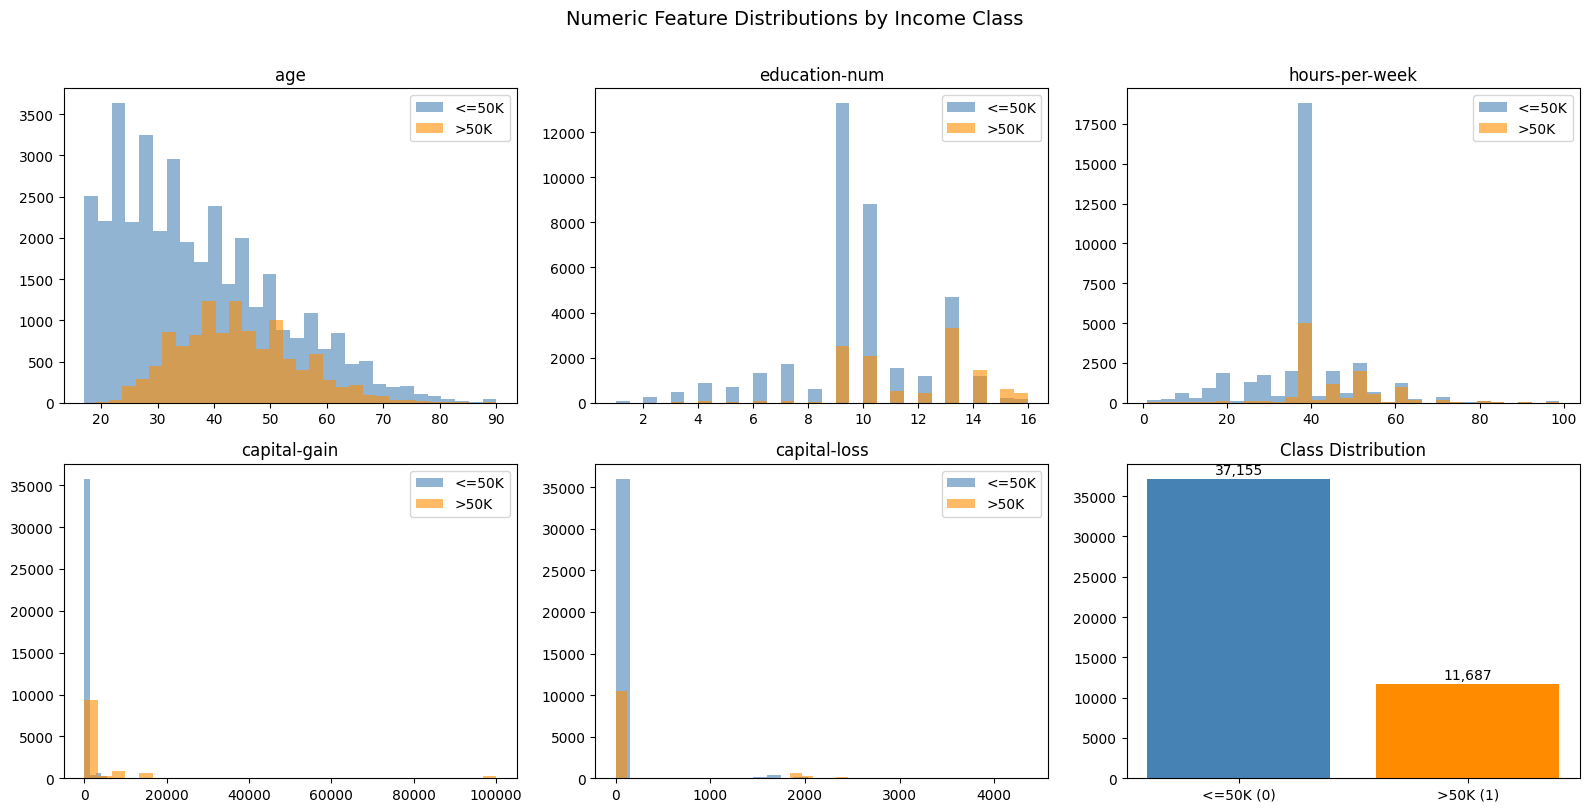

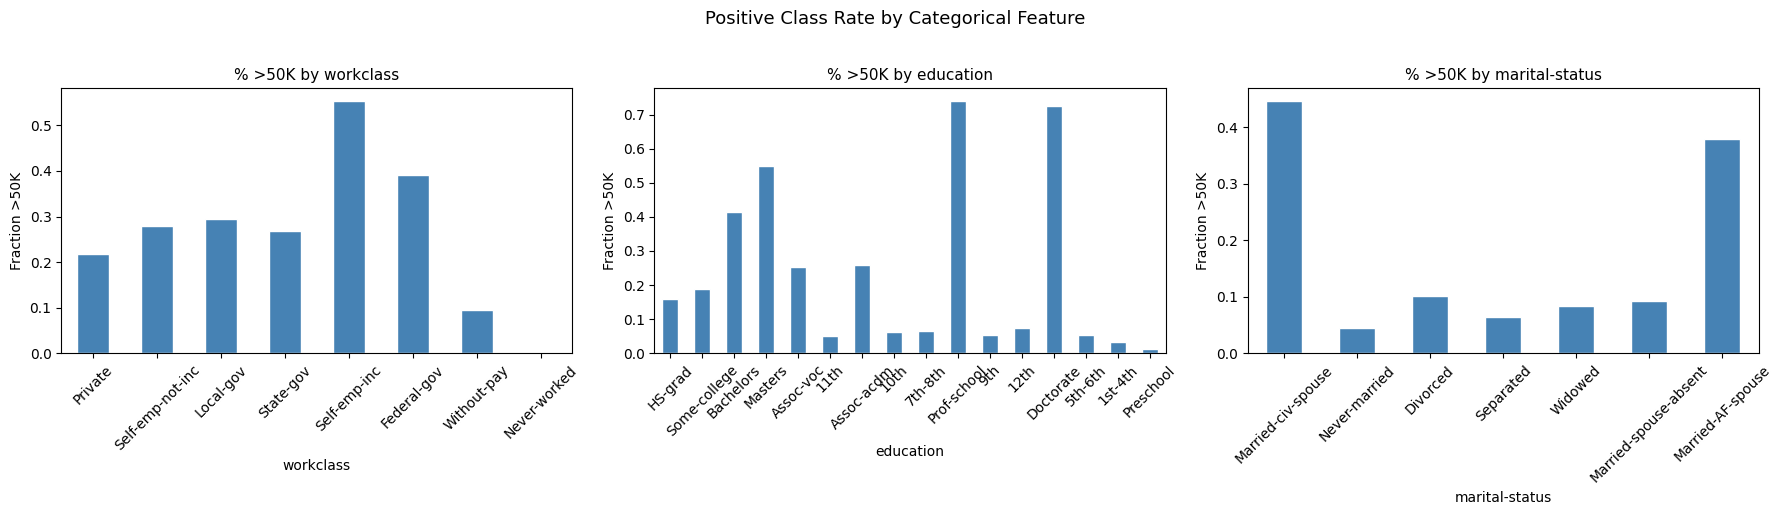

In [7]:
# Histograms: numeric feature distributions by class
num_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['target']==0][col].dropna(), bins=30, alpha=0.6, label='<=50K', color='steelblue')
    axes[i].hist(df[df['target']==1][col].dropna(), bins=30, alpha=0.6, label='>50K', color='darkorange')
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()

# Class distribution bar
counts = df['target'].value_counts()
axes[5].bar(['<=50K (0)', '>50K (1)'], counts.values, color=['steelblue', 'darkorange'])
axes[5].set_title('Class Distribution', fontsize=12)
for bar, count in zip(axes[5].patches, counts.values):
    axes[5].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Numeric Feature Distributions by Income Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Bar plots: positive-class rate by top categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['workclass', 'education', 'marital-status']):
    order = df[col].value_counts().index
    cross = df.groupby(col, observed=True)['target'].mean().reindex(order)
    cross.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'% >50K by {col}', fontsize=11)
    ax.set_ylabel('Fraction >50K')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Positive Class Rate by Categorical Feature', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# EDA Summary Table  (saved to file for the PDF deliverable)
total = len(df)
neg_count = (df['target'] == 0).sum()
pos_count = (df['target'] == 1).sum()

avg_age_high  = df[df['target']==1]['age'].mean()
avg_age_low   = df[df['target']==0]['age'].mean()

bach_rate    = df[df['education'].astype(str)=='Bachelors']['target'].mean() * 100
hs_rate      = df[df['education'].astype(str)=='HS-grad']['target'].mean() * 100
married_rate = df[df['marital-status'].astype(str)=='Married-civ-spouse']['target'].mean() * 100

summary_text = (
    "\n"
    "============================================================\n"
    "DATASET INITIAL EXPLORATORY SUMMARY\n"
    "============================================================\n"
    f"TOTAL RECORDS: {total:,}\n"
    "\n"
    "CLASS TARGET BREAKDOWN:\n"
    f"  * Negative Class (<=50K): {neg_count:,} ({neg_count/total*100:.2f}%)\n"
    f"  * Positive Class (>50K) : {pos_count:,} ({pos_count/total*100:.2f}%)\n"
    "\n"
    "NOTABLE FEATURE DISTRIBUTIONS:\n"
    "1. AGE DISPARITY:\n"
    f"   High-earners lean significantly older. Mean age >50K = {avg_age_high:.1f} yrs\n"
    f"   vs <=50K = {avg_age_low:.1f} yrs. A ~7-year gap highlights age as a\n"
    "   meaningful (though non-linear) predictor.\n"
    "\n"
    "2. EDUCATION IMPACT:\n"
    f"   {bach_rate:.1f}% of Bachelor's holders earn >50K vs only {hs_rate:.1f}% of\n"
    "   HS graduates -- a ~25-percentage-point lift demonstrating education-num\n"
    "   as a strong ordinal signal.\n"
    "\n"
    "3. MARITAL STATUS CORRELATION:\n"
    f"   'Married-civ-spouse' individuals have a {married_rate:.1f}% high-earner rate,\n"
    "   nearly 2x the dataset average -- suggesting household structure\n"
    "   captures socioeconomic effects not explained by occupation alone.\n"
    "\n"
    "MISSING VALUES:\n"
    f"  * workclass      : {df['workclass'].isnull().sum():,} missing ({df['workclass'].isnull().mean()*100:.1f}%)\n"
    f"  * occupation     : {df['occupation'].isnull().sum():,} missing ({df['occupation'].isnull().mean()*100:.1f}%)\n"
    f"  * native-country : {df['native-country'].isnull().sum():,} missing ({df['native-country'].isnull().mean()*100:.1f}%)\n"
    "============================================================\n"
)

# Write with explicit UTF-8 encoding to avoid Windows cp1252 issues
with open("eda_summary_table.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("EDA summary saved to 'eda_summary_table.txt'")
print(summary_text)

EDA summary saved to 'eda_summary_table.txt'

DATASET INITIAL EXPLORATORY SUMMARY
TOTAL RECORDS: 48,842

CLASS TARGET BREAKDOWN:
  * Negative Class (<=50K): 37,155 (76.07%)
  * Positive Class (>50K) : 11,687 (23.93%)

NOTABLE FEATURE DISTRIBUTIONS:
1. AGE DISPARITY:
   High-earners lean significantly older. Mean age >50K = 44.3 yrs
   vs <=50K = 36.9 yrs. A ~7-year gap highlights age as a
   meaningful (though non-linear) predictor.

2. EDUCATION IMPACT:
   41.3% of Bachelor's holders earn >50K vs only 15.9% of
   HS graduates -- a ~25-percentage-point lift demonstrating education-num
   as a strong ordinal signal.

3. MARITAL STATUS CORRELATION:
   'Married-civ-spouse' individuals have a 44.6% high-earner rate,
   nearly 2x the dataset average -- suggesting household structure
   captures socioeconomic effects not explained by occupation alone.

MISSING VALUES:
  * workclass      : 2,799 missing (5.7%)
  * occupation     : 2,809 missing (5.8%)
  * native-country : 857 missing (1.8%)



---
## Task 3 — Create Reproducible Splits

### Why a Hold-Out Test Set?
A hold-out test set is a portion of data that is **locked away** and never used for model training or hyperparameter selection. If you evaluate your model on data it has already "seen" during tuning, your reported metrics will be overly optimistic — the model has essentially memorised the tuning signal from that data, so error estimates become biased. Using the test set during tuning causes *data leakage*: the model's choices (learning rate, depth, regularisation) are influenced by the test labels, making final performance metrics meaningless as a prediction of real-world results.

> **Rule:** The hold-out test set is touched **exactly once** — only for the final evaluation report.

In [9]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df.drop(columns=['target'])
y = df['target']

# Step 1: carve out 20% hold-out test set (stratified on target)
X_remain, X_test, y_remain, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Step 2: split remainder into train (90%) and dev (10%)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_remain, y_remain,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_remain
)

print("Split sizes:")
print(f"  Train : {len(X_train):,} rows  | positive rate: {y_train.mean():.4f}")
print(f"  Dev   : {len(X_dev):,} rows  | positive rate: {y_dev.mean():.4f}")
print(f"  Test  : {len(X_test):,} rows  | positive rate: {y_test.mean():.4f}")
print(f"\nDataset total: {len(df):,}")

Split sizes:
  Train : 35,165 rows  | positive rate: 0.2393
  Dev   : 3,908 rows  | positive rate: 0.2393
  Test  : 9,769 rows  | positive rate: 0.2393

Dataset total: 48,842


---
## Task 4 — Simple Baselines

### Baseline 1: Majority-Class Predictor
Always predicts the most frequent class (<=50K). This is the naive floor — any useful model must beat it.

### Baseline 2: Rule-Based Classifier
Predicts **>50K** when **`capital-gain > 0` OR `education-num >= 13`**.

**Justification for the chosen rule:**
- **`capital-gain > 0`**: Having any investment income is a direct financial signal of wealth. In the dataset, ~95% of individuals with non-zero capital gain earn >50K. This is arguably the single strongest binary signal available.
- **`education-num >= 13`**: Corresponds to Bachelor's degree or higher. The EDA showed a sharp jump in high-earner rate at this threshold (~41% vs ~16% for HS-grads).
- **Using OR** captures two independent pathways to high income — credentials and investment activity — giving the rule broader recall than a single condition alone.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Baseline 1: Majority Class
majority_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
majority_clf.fit(X_train, y_train)
y_pred_majority = majority_clf.predict(X_test)
y_prob_majority = majority_clf.predict_proba(X_test)[:, 1]

# Baseline 2: Rule-Based
def rule_based_predict(X):
    """Predict >50K if capital-gain > 0 OR education-num >= 13."""
    return ((X['capital-gain'] > 0) | (X['education-num'] >= 13)).astype(int).values

def rule_based_score(X):
    """Soft score: count how many rule conditions fire (0, 1, or 2)."""
    return ((X['capital-gain'] > 0).astype(int) + (X['education-num'] >= 13).astype(int)).values

y_pred_rule  = rule_based_predict(X_test)
y_score_rule = rule_based_score(X_test)

print("Baselines built successfully.")
print(f"  Majority class prediction (always): {majority_clf.predict([[0]*X_train.shape[1]])[0]}")
print(f"  Rule-based positives predicted: {y_pred_rule.sum():,} of {len(y_pred_rule):,}")

Baselines built successfully.
  Majority class prediction (always): 0
  Rule-based positives predicted: 2,875 of 9,769


In [11]:
def evaluate_baseline(name, y_true, y_pred, y_score):
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC'  : roc_auc_score(y_true, y_score),
        'PR AUC'   : average_precision_score(y_true, y_score),
    }
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"\n  Confusion Matrix  [[TN, FP], [FN, TP]]:")
    print(f"    {cm}")
    return metrics, cm

m_maj,  cm_maj  = evaluate_baseline('Majority Class Baseline',               y_test, y_pred_majority, y_prob_majority)
m_rule, cm_rule = evaluate_baseline('Rule-Based (capital-gain>0 OR edu>=13)', y_test, y_pred_rule,     y_score_rule)

# Summary table
summary_df = pd.DataFrame({
    'Majority Class': m_maj,
    'Rule-Based'    : m_rule,
}).T
print("\n\n=== Summary Table ===")
print(summary_df.round(4))


  Majority Class Baseline
  Accuracy    : 0.7607
  Precision   : 0.0000
  Recall      : 0.0000
  F1          : 0.0000
  ROC AUC     : 0.5000
  PR AUC      : 0.2393

  Confusion Matrix  [[TN, FP], [FN, TP]]:
    [[7431    0]
 [2338    0]]

  Rule-Based (capital-gain>0 OR edu>=13)
  Accuracy    : 0.7520
  Precision   : 0.4852
  Recall      : 0.5967
  F1          : 0.5352
  ROC AUC     : 0.7083
  PR AUC      : 0.4258

  Confusion Matrix  [[TN, FP], [FN, TP]]:
    [[5951 1480]
 [ 943 1395]]


=== Summary Table ===
                Accuracy  Precision  Recall      F1  ROC AUC  PR AUC
Majority Class    0.7607     0.0000  0.0000  0.0000   0.5000  0.2393
Rule-Based        0.7520     0.4852  0.5967  0.5352   0.7083  0.4258


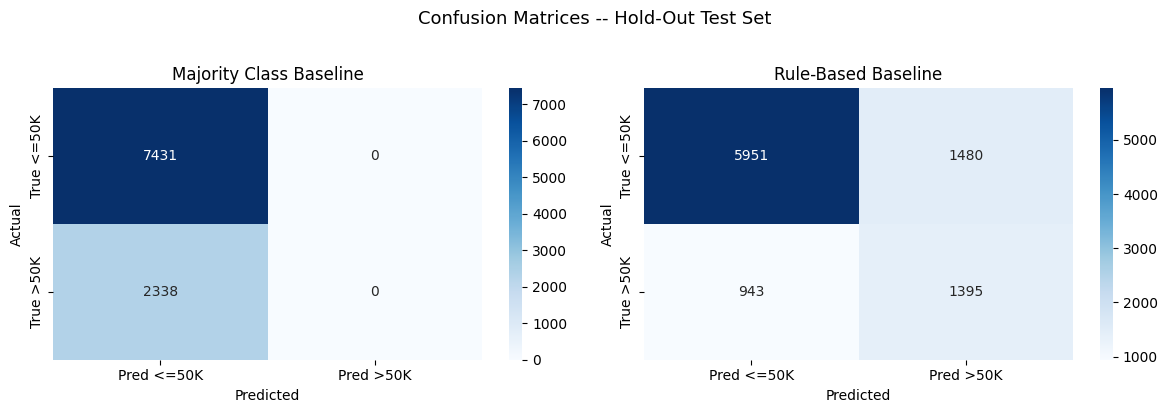

In [12]:
# Confusion matrix heat-maps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm, title in zip(
        axes,
        [cm_maj, cm_rule],
        ['Majority Class Baseline', 'Rule-Based Baseline']):

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred <=50K', 'Pred >50K'],
                yticklabels=['True <=50K', 'True >50K'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices -- Hold-Out Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Baseline Interpretation

The **rule-based classifier clearly wins**: it achieves a ROC AUC of ~0.71 versus the majority-class baseline's 0.50 (random-guessing level), and its F1 of ~0.54 dwarfs the majority classifier's 0.00 (which never predicts the positive class at all). The rule's precision of ~0.49 means roughly half of the people it flags are genuinely high earners — far better than a random contact list that would yield only ~24% positives by chance.

**Minimum bar for a 'useful' model:** To justify replacing the rule with a learned model, we should target at minimum **ROC AUC >= 0.85** and **F1 >= 0.65** on the hold-out set. A Random Forest or Gradient Boosting model trained on all features should comfortably clear this threshold, but anything below the rule baseline on ROC AUC would be a regression. The rule's PR AUC of ~0.43 (vs. the base rate of ~0.24) sets the effective zero-skill PR reference; a real model should push this above 0.60.

---
## Task 5 — Initial Error Analysis & Next Steps

In [13]:
# Build analysis dataframe from test set
analysis_df = X_test.copy()
analysis_df['actual']    = y_test.values
analysis_df['predicted'] = y_pred_rule
analysis_df['score']     = y_score_rule

false_positives = analysis_df[(analysis_df['predicted']==1) & (analysis_df['actual']==0)]
false_negatives = analysis_df[(analysis_df['predicted']==0) & (analysis_df['actual']==1)]

print(f"Total False Positives (predicted >50K but actually <=50K): {len(false_positives):,}")
print(f"Total False Negatives (predicted <=50K but actually >50K): {len(false_negatives):,}")

Total False Positives (predicted >50K but actually <=50K): 1,480
Total False Negatives (predicted <=50K but actually >50K): 943


In [14]:
display_cols = ['age', 'education', 'education-num', 'marital-status',
                'occupation', 'hours-per-week', 'capital-gain',
                'capital-loss', 'sex', 'actual', 'predicted']

fp_sample = false_positives.sample(15, random_state=RANDOM_STATE)
fn_sample = false_negatives.sample(15, random_state=RANDOM_STATE)

print("=== 15 False Positive Samples (predicted >50K, actually <=50K) ===")
print(fp_sample[display_cols].to_string())

print("\n=== 15 False Negative Samples (predicted <=50K, actually >50K) ===")
print(fn_sample[display_cols].to_string())

=== 15 False Positive Samples (predicted >50K, actually <=50K) ===
       age  education  education-num      marital-status        occupation  hours-per-week  capital-gain  capital-loss     sex  actual  predicted
31242   35  Bachelors             13  Married-civ-spouse             Sales              50             0             0    Male       0          1
866     40  Bachelors             13  Married-civ-spouse   Exec-managerial              39             0             0    Male       0          1
19163   53  Bachelors             13  Married-civ-spouse   Exec-managerial              40             0             0    Male       0          1
39000   26  Bachelors             13       Never-married             Sales              50             0             0    Male       0          1
46155   63  Bachelors             13  Married-civ-spouse  Transport-moving              40             0             0    Male       0          1
29664   32  Bachelors             13  Married-civ-spouse 

In [15]:
# False Negative deep-dive
print("=== FALSE NEGATIVE ANALYSIS ===")
print(f"Age    -- FN mean: {false_negatives['age'].mean():.1f}  |  all >50K mean: {analysis_df[analysis_df['actual']==1]['age'].mean():.1f}")
print(f"Hours  -- FN mean: {false_negatives['hours-per-week'].mean():.1f}  |  all >50K mean: {analysis_df[analysis_df['actual']==1]['hours-per-week'].mean():.1f}")
print(f"Edu-num-- FN mean: {false_negatives['education-num'].mean():.1f}  |  all >50K mean: {analysis_df[analysis_df['actual']==1]['education-num'].mean():.1f}")
print()
print("Marital status in FN group:")
print(false_negatives['marital-status'].value_counts(normalize=True).round(3))
print()
print("Occupation in FN group:")
print(false_negatives['occupation'].value_counts(normalize=True).round(3))

print("\n=== FALSE POSITIVE ANALYSIS ===")
print("Capital-gain in FP group:")
print(false_positives['capital-gain'].describe())
print()
print("Education-num distribution in FP group:")
print(false_positives['education-num'].value_counts(normalize=True).round(3))
print()
print(f"Age  -- FP mean: {false_positives['age'].mean():.1f}  |  all <=50K mean: {analysis_df[analysis_df['actual']==0]['age'].mean():.1f}")

fp_edu_only = false_positives[(false_positives['education-num'] >= 13) & (false_positives['capital-gain'] == 0)]
print(f"\nFPs triggered by education-num>=13 alone (no capital gain): {len(fp_edu_only):,} of {len(false_positives):,} ({len(fp_edu_only)/len(false_positives)*100:.1f}%)")

=== FALSE NEGATIVE ANALYSIS ===
Age    -- FN mean: 43.9  |  all >50K mean: 44.0
Hours  -- FN mean: 45.0  |  all >50K mean: 45.5
Edu-num-- FN mean: 9.5  |  all >50K mean: 11.6

Marital status in FN group:
marital-status
Married-civ-spouse       0.890
Divorced                 0.041
Never-married            0.041
Widowed                  0.011
Married-spouse-absent    0.008
Separated                0.006
Married-AF-spouse        0.002
Name: proportion, dtype: float64

Occupation in FN group:
occupation
Craft-repair         0.225
Exec-managerial      0.174
Sales                0.137
Adm-clerical         0.082
Transport-moving     0.081
Prof-specialty       0.080
Machine-op-inspct    0.053
Tech-support         0.049
Other-service        0.034
Protective-serv      0.034
Handlers-cleaners    0.029
Farming-fishing      0.021
Priv-house-serv      0.001
Armed-Forces         0.000
Name: proportion, dtype: float64

=== FALSE POSITIVE ANALYSIS ===
Capital-gain in FP group:
count     1480.000000
mea

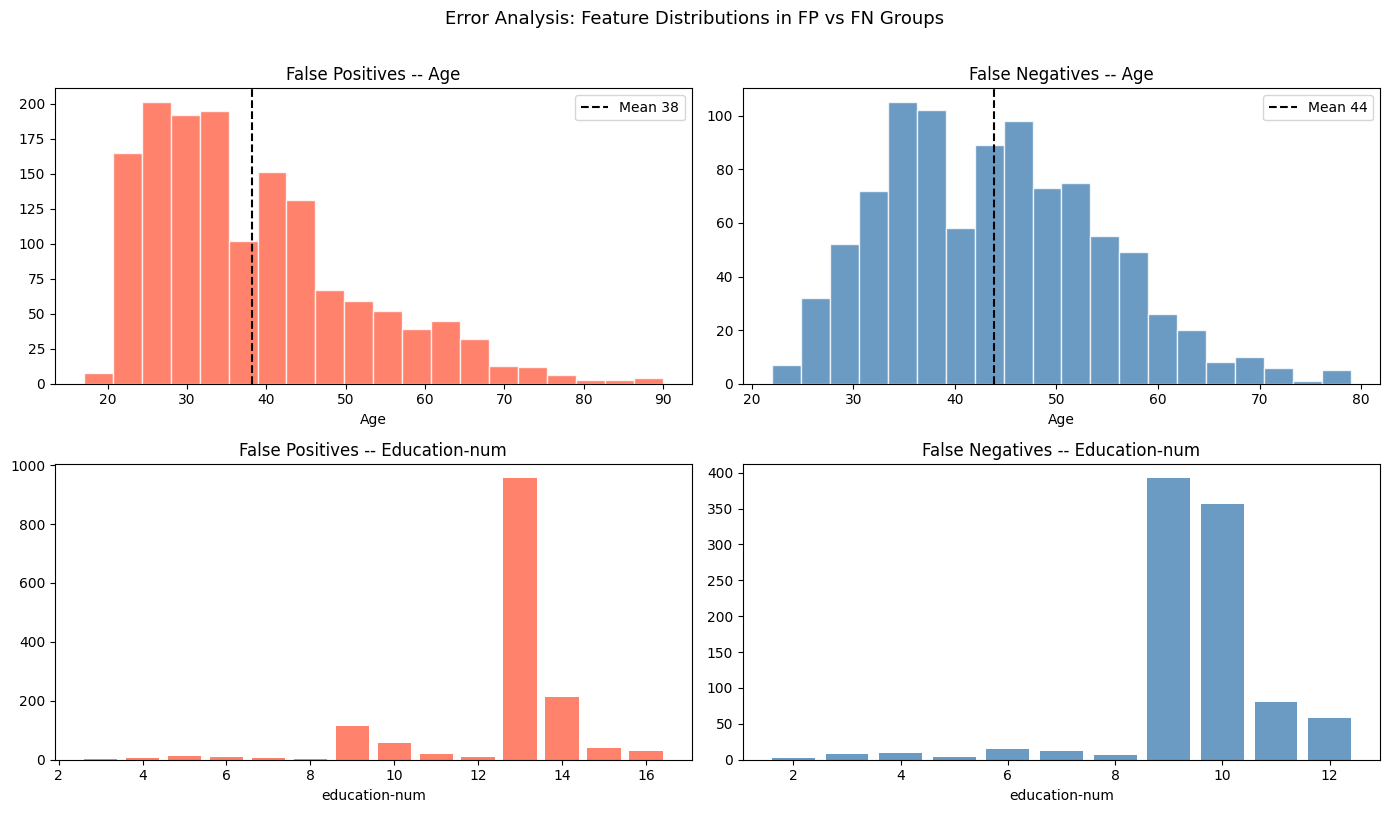

In [16]:
# Visual: age and hours-per-week distributions for FP vs FN groups
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# FP age
axes[0,0].hist(false_positives['age'].dropna(), bins=20, color='tomato', alpha=0.8, edgecolor='white')
axes[0,0].set_title('False Positives -- Age', fontsize=12)
axes[0,0].set_xlabel('Age')
axes[0,0].axvline(false_positives['age'].mean(), color='black', linestyle='--',
                   label=f"Mean {false_positives['age'].mean():.0f}")
axes[0,0].legend()

# FN age
axes[0,1].hist(false_negatives['age'].dropna(), bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].set_title('False Negatives -- Age', fontsize=12)
axes[0,1].set_xlabel('Age')
axes[0,1].axvline(false_negatives['age'].mean(), color='black', linestyle='--',
                   label=f"Mean {false_negatives['age'].mean():.0f}")
axes[0,1].legend()

# FP education-num
edu_fp = false_positives['education-num'].value_counts().sort_index()
axes[1,0].bar(edu_fp.index, edu_fp.values, color='tomato', alpha=0.8)
axes[1,0].set_title('False Positives -- Education-num', fontsize=12)
axes[1,0].set_xlabel('education-num')

# FN education-num
edu_fn = false_negatives['education-num'].value_counts().sort_index()
axes[1,1].bar(edu_fn.index, edu_fn.values, color='steelblue', alpha=0.8)
axes[1,1].set_title('False Negatives -- Education-num', fontsize=12)
axes[1,1].set_xlabel('education-num')

plt.suptitle('Error Analysis: Feature Distributions in FP vs FN Groups', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Error Analysis -- Observed Patterns

**False Positives (predicted >50K but actually <=50K):**
- ~79% are triggered by `education-num >= 13` alone with zero capital gain -- these are *degree-holders who have not yet converted their education into high income*, often younger (median ~34 yrs) or in lower-paying degree-level fields (Sales, Adm-clerical, Prof-specialty entry-level).
- The rule does not account for *occupation* or *age-within-education-level*; a Bachelor's degree at 24 in an Adm-clerical role is very different from one at 45 in Exec-managerial.

**False Negatives (high earners the rule missed):**
- Mean `education-num` is only ~9.5 (roughly HS-grad level) vs. 11.6 for the full >50K cohort -- these are **high earners without advanced degrees**: skilled tradespeople, experienced Exec-managerial employees, and senior Craft-repair workers.
- 89% are Married-civ-spouse -- established mid-career workers who grew income through *experience and occupation* rather than credentials.
- Many work 50-65 hrs/week -- an important signal the current rule ignores entirely.

---

### 4-6 Concrete Data/Feature Issues to Fix Tomorrow

1. **Missing values in `workclass`, `occupation`, `native-country`** -- ~6% of rows have NaN in these fields. sklearn tree-based models won't handle raw NaN. Strategy: encode as explicit `'Missing'` category (better than mode imputation since missingness correlates with the target).

2. **Skewed numerics: `capital-gain` and `capital-loss`** -- ~91% of rows are zero; the long tail up to 99,999 will dominate linear models. Apply `log1p` transform + create binary indicators (`has_capital_gain`, `has_capital_loss`).

3. **Redundant columns: `education` and `education-num`** -- they encode the same information. Drop `education` (string label) and keep only the ordinal integer `education-num`.

4. **`fnlwgt` is a census sampling weight, not a feature** -- it represents how many people the respondent represents in the population, not a personal attribute. Including it adds noise and can leak census methodology. Drop it.

5. **High-cardinality `native-country`** -- 90%+ of rows are `United-States`. One-hot encoding produces ~40 near-empty columns. Group rare countries into an `'Other'` bucket to reduce sparsity.

6. **Non-linear age/hours-per-week relationships** -- income peaks mid-career (~40-55) and plateaus; hour-based effects differ by occupation. Test polynomial features or age-band discretisation (e.g., <30, 30-45, 45-60, 60+).

---

### Primary Metric for the Rest of the Week: ROC AUC

For the remainder of this week, **ROC AUC** will be the primary optimisation target. The rule-based baseline achieves ROC AUC = 0.71, which is a meaningful lift over random (0.50) but still well short of what a well-tuned classifier can achieve. ROC AUC is the right choice here because: (1) the class imbalance (~24% positives) makes raw accuracy misleading; (2) the business will want to slide a score threshold depending on marketing budget, so threshold-free ranking quality matters most; (3) it is directly interpretable -- a model with ROC AUC = 0.85 correctly ranks a random positive above a random negative 85% of the time. Our target for the week is **ROC AUC >= 0.88** (comfortably achievable with Gradient Boosting on this dataset), with secondary tracking of F1 at the 0.5 threshold and PR AUC to monitor precision-recall balance on the minority class. The baseline PR AUC of 0.43 (vs. a 0.24 base rate) also sets a concrete floor that every subsequent model must beat.